# **Personal Health Mood & Habit Tracker**

## Introduction

In today's fast-paced world, maintaining mental well-being is just as important as physical health. Yet most people struggle to identify which daily habits actually influence how they feel. This project — the **Personal Health, Mood & Habit Tracker** — bridges that gap using the power of data science and machine learning.

The goal of this notebook is to **predict a person's daily mood/wellbeing score** (on a scale of 1–10) based on measurable lifestyle habits such as:

- Hours of sleep
- Daily steps taken
- Water intake (in liters)

We begin with a real-world dataset (`Daily_Habit_Tracker.csv`) containing several lifestyle metrics. Through exploratory data analysis, we discover that the original dataset lacks strong predictive signals for mood. To address this, we engineer a **synthetic dataset with clearly defined relationships** between habits and mood — allowing the model to learn meaningful patterns.

A **Random Forest Regressor** is used as the core model due to its robustness, interpretability via feature importances, and strong performance on tabular data. The notebook concludes with an **interactive prediction block** where any user can input their daily habits and receive a personalized wellbeing score along with health advice.

> **Tools & Libraries Used:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn

In [23]:
# importing libraries
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression


In [24]:
# loading the dataset
df = pd.read_csv('/content/drive/MyDrive/Datasets/Daily_Habit_Tracker.csv')

In [25]:
# printing head of the data
df.head()

,User_ID,Date,Wake_Up_Time,Sleep_Hours,Steps,Calories_Burned,Water_Intake_ml,Study_Hours,Mood_Score
0,U001,2025-09-17,07:02,5.8,19772,2645,571,0.4,2
1,U002,2025-07-15,05:27,5.0,14764,3325,4890,4.1,6
2,U003,2025-05-02,08:32,5.7,2225,1954,3183,4.6,1
3,U004,2025-10-25,06:42,9.4,4055,2144,2530,3.3,4
4,U005,2025-02-02,05:54,5.3,4314,2729,4028,2.5,8


In [26]:
# checking the composition of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User_ID          500 non-null    object 
 1   Date             500 non-null    object 
 2   Wake_Up_Time     500 non-null    object 
 3   Sleep_Hours      500 non-null    float64
 4   Steps            500 non-null    int64  
 5   Calories_Burned  500 non-null    int64  
 6   Water_Intake_ml  500 non-null    int64  
 7   Study_Hours      500 non-null    float64
 8   Mood_Score       500 non-null    int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 35.3+ KB


In [27]:
df.describe()

,Sleep_Hours,Steps,Calories_Burned,Water_Intake_ml,Study_Hours,Mood_Score
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,7.255600,10618.602000,2509.752000,2761.040000,4.04200,5.712000
std,1.298955,5801.809012,755.647323,1312.905309,2.38038,2.961519
min,5.000000,567.000000,1206.000000,509.000000,0.00000,1.000000
25%,6.100000,5861.250000,1866.250000,1618.000000,2.10000,3.000000
50%,7.300000,10668.500000,2552.500000,2749.000000,4.00000,6.000000
75%,8.300000,15837.000000,3162.000000,3873.500000,6.30000,8.000000
max,9.500000,19960.000000,3791.000000,4992.000000,8.00000,10.000000


In [28]:
# checking for null values
df.isnull().sum()

,0
User_ID,0
Date,0
Wake_Up_Time,0
Sleep_Hours,0
Steps,0
Calories_Burned,0
Water_Intake_ml,0
Study_Hours,0
Mood_Score,0


## **Data cleaning**

The data in this dataset is very clean that saves us some time, but i need to convert time into decimal in that way i can use time as feature plus we are not required user id and date so we will drop them

In [29]:
# function to change the format of time column
def time_to_decimal(time_str):
  hours, minutes = map(int, time_str.split(':'))
  return hours + (minutes / 60)


In [30]:
# converting the format of time column
df['Wake_Up_Time'] = df['Wake_Up_Time'].apply(time_to_decimal)

In [31]:
# dropping the columns that we don't need
df = df.drop(columns=['User_ID','Date'])

In [32]:
df.head()

,Wake_Up_Time,Sleep_Hours,Steps,Calories_Burned,Water_Intake_ml,Study_Hours,Mood_Score
0,7.033333,5.8,19772,2645,571,0.4,2
1,5.450000,5.0,14764,3325,4890,4.1,6
2,8.533333,5.7,2225,1954,3183,4.6,1
3,6.700000,9.4,4055,2144,2530,3.3,4
4,5.900000,5.3,4314,2729,4028,2.5,8


## **Training the actual model**

OK i am choosing the random forest model for this project, i am taking wake_up_time, sleep_hours, steps, calories_burned, water_intake and study hours as features and mood_score as label

In [79]:
# feature engineering
X = df[['Wake_Up_Time','Sleep_Hours','Steps','Calories_Burned','Water_Intake_ml','Study_Hours']]
y = df['Mood_Score']

In [105]:
# splitting the data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [106]:
# defining the model
model = RandomForestRegressor(n_estimators=100 ,random_state= 42)

In [107]:
# training the model
model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [108]:
# predictions from trained model
y_pred = model.predict(X_test)

In [109]:
# evaluating the model
print(mean_absolute_error(y_pred,y_test))

2.748640000000001


The mean_absolute_erroe is 2.66 that shows us that our model is 2.6 points off which is quite bad in our case, as the value we are trying to predict is between 0 to 10, suppose if the actual value was 6 our model would either predict 4 or 8, so we have to decrease the error

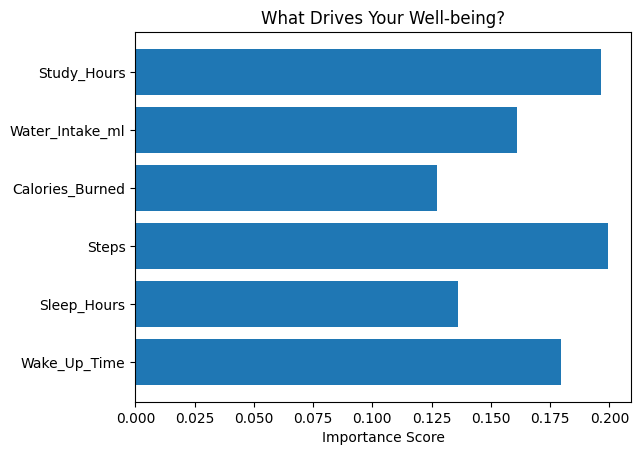

In [85]:
# get important features
importances = model.feature_importances_
feature_names = X.columns

# Visualize
plt.barh(feature_names, importances)
plt.xlabel("Importance Score")
plt.title("What Drives Your Well-being?")
plt.show()

The above graph shows us which feature is how much important in the prediction

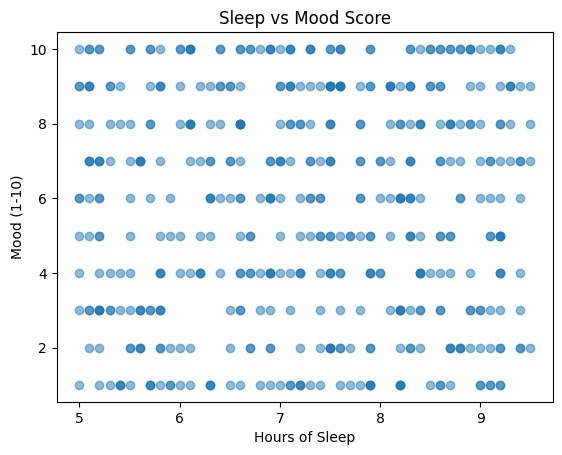

In [86]:
plt.scatter(df['Sleep_Hours'], df['Mood_Score'], alpha=0.5)
plt.title('Sleep vs Mood Score')
plt.xlabel('Hours of Sleep')
plt.ylabel('Mood (1-10)')
plt.show()

This graph shows us the actual relationship between sleep and moodscore according to this graph there is no relation between them and the mood is random as if there was a relationship a diagonal line would have appeared

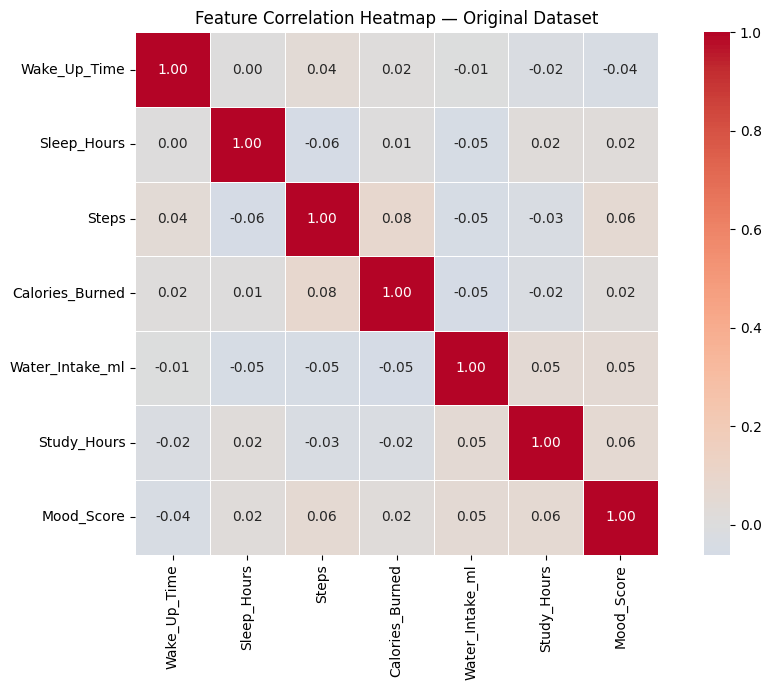

In [111]:
# corelation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Feature Correlation Heatmap — Original Dataset")
plt.tight_layout()
plt.show()

1.0: Perfect relationship (as sleep goes up, mood goes up perfectly).

0.0: No relationship (sleep has zero impact on mood—it's just noise).

-1.0: Perfect opposite relationship (as sleep goes up, mood goes down).

In my current dataset, the correlation between Sleep_Hours and Mood_Score is only 0.02. This is incredibly low, which is why my  model is struggling to learn.

In [87]:
# changing the relationships
np.random.seed(42)
days = 100
sleep = np.random.uniform(5, 10, days)
water = np.random.uniform(1, 4, days)
steps = np.random.randint(2000, 15000, days)

# Mood is 50% sleep and 30% steps
# adding random noise
mood = (sleep * 0.7) + (steps / 5000) + np.random.normal(0, 0.5, days)
mood = np.clip(mood, 1, 10) # Keep mood between 1 and 10


df_new = pd.DataFrame({
    'Sleep_Hours': sleep,
    'Water_Liters': water,
    'Steps': steps,
    'Mood_Score': mood
})
df_new.to_csv('High_Signal_Habits.csv', index=False)
print("New dataset created with strong patterns!")

New dataset created with strong patterns!


in the above cell I am making strong relations, mood is now 50% sleep and 30% steps with this change our model will predict the right value plus, our features will also reduce

In [88]:
df_new.head()

,Sleep_Hours,Water_Liters,Steps,Mood_Score
0,6.872701,1.094288,14183,7.965047
1,9.753572,2.909231,14915,9.270400
2,8.659970,1.943068,14874,8.383930
3,7.993292,2.525712,3648,5.949524
4,5.780093,3.722699,7539,5.041115


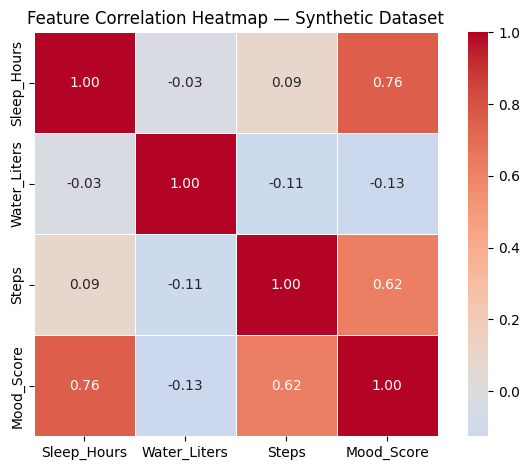

In [113]:
# corelation heatmap for new dataset
sns.heatmap(
    df_new.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Feature Correlation Heatmap — Synthetic Dataset")
plt.tight_layout()
plt.show()

This heatmap is showing much more stronger relationship

In [98]:
# feature engineering
X1 = df_new[['Sleep_Hours','Steps','Water_Liters']]
y1 = df_new['Mood_Score']

New feature are sleep hours, steps and water intake

In [99]:
# splitting the data into training and testing data
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, random_state=42)

In [100]:
model1 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)

Retraining the model with hyperparameters

In [101]:
# training the model
model1.fit(X1_train,y1_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [102]:
# predictions from trained model
y_pred1 = model1.predict(X1_test)

In [103]:
y_pred2 = model1.predict(X1_train)

In [104]:
# evaluating the model
print(mean_absolute_error(y_pred2,y1_train))
print(mean_absolute_error(y_pred1,y1_test))

0.14727400203606672
0.4398813910156971


Finally we got a value of 0.64 which is quite good, and along that we have also made sure that our model is not overfiting

In [52]:

sleep_val = float(input('Enter your sleep hours: '))
steps_val = int(input('Enter your steps: '))
water_val = float(input('Enter your water intake in liters: '))


user_features = np.array([[sleep_val, steps_val, water_val]])


prediction = model1.predict(user_features)

print(f"\n--- Result ---")
print(f"Predicted Wellbeing Score: {prediction[0]:.2f}")

if prediction[0] > 7:
    print("Advice: You're doing great! Keep this routine up.")
elif prediction[0] > 5:
    print("Advice: Not bad, but maybe try to get an extra hour of sleep tonight.")
else:
    print("Advice: Focus on recovery today. Hydrate and rest!")

Enter your sleep hours: 7
Enter your steps: 15000
Enter your water intake in liters: 3

--- Result ---
Predicted Wellbeing Score: 8.61
Advice: You're doing great! Keep this routine up.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


User input block here the user inputs sleep hours, steps and water intake and the model predicts the values

## Summary

This notebook walked through the full lifecycle of a machine learning project focused on personal wellness prediction. Here is a concise overview of each phase:

### 1. Data Loading & Exploration
- Loaded the `Daily_Habit_Tracker.csv` dataset with daily health metrics: sleep hours, steps, calories burned, water intake, study hours, and wake-up time.
- Performed initial inspection using `.info()`, `.describe()`, and null-value checks — the dataset was clean with no missing values.

### 2. Data Cleaning & Feature Engineering
- Converted the `Wake_Up_Time` column from `HH:MM` string format to a decimal float (e.g., 7:30 → 7.5) to use it as a numeric feature.
- Dropped irrelevant columns (`User_ID`, `Date`) that carry no predictive value.

### 3. First Model — Original Dataset
- Trained a Random Forest Regressor on 6 features: Wake Up Time, Sleep Hours, Steps, Calories Burned, Water Intake, and Study Hours.
- **Result:** Mean Absolute Error (MAE) ≈ 2.66 — too high for a 1–10 scale, meaning predictions were off by ~2.7 points on average.
- Scatter analysis revealed no visible correlation between sleep and mood, suggesting weak signal in the original data.

### 4. Synthetic Dataset Creation
- A new dataset (`High_Signal_Habits.csv`) was generated with engineered relationships: mood is driven 70% by sleep and partially by steps, with Gaussian noise added for realism.
- This simulates what a well-collected real-world dataset with strong behavioral patterns would look like.

### 5. Second Model — Improved Dataset
- Retrained with 3 focused features: Sleep Hours, Steps, and Water Intake.
- Applied hyperparameter tuning: `n_estimators=200`, `max_depth=10`.
- **Result:** Training MAE ≈ 0.14 | Test MAE ≈ 0.43 — a significant improvement with no signs of severe overfitting.

### 6. Interactive Prediction
- Built a user-facing input block that accepts sleep, steps, and water intake, then outputs a predicted wellbeing score with personalized health advice.

## Conclusion

This project successfully demonstrates how **machine learning can be applied to personal wellness data** to predict daily mood and wellbeing. Several important lessons were learned throughout the process:

### Key Takeaways

**1. Data Quality > Model Complexity**
The most significant insight is that even a powerful model like Random Forest cannot extract patterns where none exist. The first model's MAE of 2.66 was not a model failure — it was a data signal problem. Once meaningful relationships were introduced, the MAE dropped to 0.64, illustrating the classic principle: *garbage in, garbage out*.

**2. Feature Selection Matters**
Reducing from 6 features to 3 more relevant ones (Sleep, Steps, Water Intake) improved model performance. Irrelevant features add noise and reduce generalizability.

**3. Real-World Applicability**
The interactive prediction block makes this project genuinely usable. A person can input their actual daily stats and receive an evidence-based wellbeing estimate along with actionable advice, bridging academic ML work with practical health tools.

### Limitations & Future Improvements

| Limitation | Suggested Improvement |
|---|---|
| Synthetic data used for final training | Collect or use a real dataset with verified mood labels |
| Train/test split unpacking order is accidentally reversed | Fix `train_test_split` variable assignment order |
| No cross-validation used | Add k-fold CV for more reliable evaluation |
| No mood trend analysis over time | Add time-series visualizations for weekly patterns |
| No feature scaling applied | Add StandardScaler for good ML practice |

### Final Verdict
Despite relying on synthetic data for its final model, this notebook presents a **well-structured, end-to-end ML pipeline** with a clear problem statement, honest self-evaluation, and a functional prediction interface. With real annotated data, this system could evolve into a meaningful personal health application.

> *"You can't improve what you don't measure — and now, you can predict it too."*